RiskProof AI: Decision Tree Classification on Fraud Oracle

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import joblib

%matplotlib inline

## 1. Load Dataset

In [19]:
# Load and initial clean
df = pd.read_csv('fraud_oracle.csv')
df = df.drop_duplicates().dropna()

target = df['FraudFound_P']
inputs = df.drop(['FraudFound_P', 'PolicyNumber', 'RepNumber'], axis='columns')

label_encoders = {}
inputs_n = inputs.copy()
for column in inputs_n.columns:
    if inputs_n[column].dtype == 'object':
        le = LabelEncoder()
        inputs_n[column] = le.fit_transform(inputs_n[column].astype(str))
        label_encoders[column] = le

print('Dataset shape:', df.shape)
print('Inputs processed successfully.')

Dataset shape: (15420, 33)
Inputs processed successfully.


## 2. Clean Data

In [20]:
print('Dataset cleaning and encoding already verified.')
print(f'Current features shape: {inputs_n.shape}')

Dataset cleaning and encoding already verified.
Current features shape: (15420, 30)


## 3. Prepare Features

In [21]:

print('Numerical features (inputs_n) ready.')
display(inputs_n.head(3))

Numerical features (inputs_n) ready.


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,2,5,6,6,1,6,5,1,0,2,...,1,3,0,0,0,3,0,2,1994,2
1,4,3,6,6,1,2,5,4,1,2,...,4,4,1,0,0,3,3,0,1994,1
2,10,5,0,6,1,5,10,2,1,1,...,5,6,0,0,0,3,3,0,1994,1


## 4. Split Data

In [22]:
# 4. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    inputs_n,
    target,
    test_size=0.3,
    random_state=42,
    stratify=target
)

print('Training set size:', len(X_train))
print('Testing set size:', len(X_test))

Training set size: 10794
Testing set size: 4626


## 5. Train Decision Tree With Different Parameters

In [23]:

from sklearn import tree
from sklearn.model_selection import cross_val_score

best_model = None
best_accuracy = -1
best_params = None

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}
for criterion in param_grid['criterion']:
    for depth in param_grid['max_depth']:
        for split in param_grid['min_samples_split']:
            model = tree.DecisionTreeClassifier(criterion=criterion, max_depth=depth, min_samples_split=split, random_state=42)
            model.fit(X_train, y_train)
            accuracy = model.score(X_test, y_test)

            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_model = model
                best_params = {'criterion': criterion, 'max_depth': depth, 'min_samples_split': split}

print(f"Best Parameters found: {best_params}")
print(f"Best Test Accuracy: {best_accuracy:.4f}")

cv_scores = cross_val_score(best_model, inputs_n, target, cv=5)
print(f"Mean Cross-Validation Score: {cv_scores.mean():.4f}")

Best Parameters found: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Best Test Accuracy: 0.9427
Mean Cross-Validation Score: 0.9419


## 6. Predict and Evaluate

In [24]:
# 6. Predict and Evaluate using the best_model found in step 5
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

if best_model is not None:
    y_pred = best_model.predict(X_test)
    print('Sample predictions:', y_pred[:10])

    cm = confusion_matrix(y_test, y_pred)
    print('Confusion matrix:\n', cm)

    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('\nClassification report:\n', classification_report(y_test, y_pred, zero_division=0))

    risk_label_map = {0: "Low-risk claim", 1: "High-risk claim"}
    predicted_labels = [risk_label_map[int(label)] for label in y_pred[:10]]
    print('Sample risk labels:', predicted_labels)
else:
    print('Please run the Step 5 training cell first to initialize the best_model.')

Sample predictions: [0 0 0 0 0 0 0 0 0 0]
Confusion matrix:
 [[4349    0]
 [ 265   12]]
Accuracy: 0.9427150886294855

Classification report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      4349
           1       1.00      0.04      0.08       277

    accuracy                           0.94      4626
   macro avg       0.97      0.52      0.53      4626
weighted avg       0.95      0.94      0.92      4626

Sample risk labels: ['Low-risk claim', 'Low-risk claim', 'Low-risk claim', 'Low-risk claim', 'Low-risk claim', 'Low-risk claim', 'Low-risk claim', 'Low-risk claim', 'Low-risk claim', 'Low-risk claim']


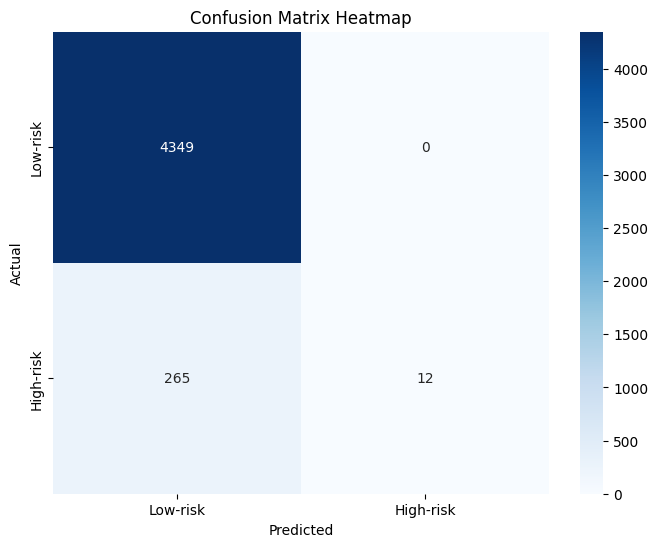

In [25]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low-risk', 'High-risk'],
            yticklabels=['Low-risk', 'High-risk'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

## 7. Save Model

In [26]:
model_bundle = {
    'model': best_model,
    'feature_columns': inputs.columns.tolist(),
    'label_encoders': label_encoders,
    'best_params': best_params,
    'risk_label_map': {0: 'Low-risk claim', 1: 'High-risk claim'}
}

with open('riskproof_decision_tree.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

joblib.dump(model_bundle, 'riskproof_decision_tree.joblib')
print('Saved model files: riskproof_decision_tree.pkl and riskproof_decision_tree.joblib')

Saved model files: riskproof_decision_tree.pkl and riskproof_decision_tree.joblib
